# E54 · Why a neuron fires: Bayesian inference of a conductance-based model from patch-clamp recordings

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: whole-cell current-clamp recordings of **one mouse visual-cortex interneuron** (an Sst-expressing, aspiny cell, specimen 464212183) from the **Allen Cell Types Database** - 21 one-second square current steps from -110 to +230 pA, extracted from the published NWB file and downsampled to 20 kHz |
| **You will learn** | What ion channels do and why a neuron fires, in plain terms · the membrane as an **RC circuit**: capacitance, leak conductance and time constant from subthreshold steps (NUTS, analytic solution, stationary AR(1) noise), and a held-out sweep that reveals a channel the model lacks · a **Hodgkin-Huxley-type model** (Na, K, slow M-type K, leak) and how to integrate a stiff ODE cheaply: **Rush-Larsen / exponential Euler**, both in Numba and inside PyMC with `scan` · why **matching the voltage trace is pathological**: a likelihood profile full of local maxima, and NUTS chains stuck in different modes with zero divergences · a **likelihood on spike features** (f-I curve, latency, spike height and width, AHP, adaptation) sampled with **`pm.Simulator` + SMC**, which finds a two-mode posterior · **sloppiness and degeneracy**: prior-whitened eigen-directions of the posterior, and very different conductance sets that fire the same way · **posterior predictions** for held-out current steps and the f-I curve |

## A neuron's electrical life, in one paragraph

A neuron is a bag of salty water wrapped in a thin fatty membrane. Pumps keep more sodium outside
and more potassium inside, so each ion "wants" to flow one way, and the inside sits at about
-65 mV relative to the outside. The membrane itself is an insulator and stores charge like a
**capacitor**. What lets current through are **ion channels**: proteins that open a pore for one
kind of ion. A few are always open (the **leak**), which makes the membrane a leaky capacitor, an
**RC circuit**. Others open and close with the voltage. When the membrane is pushed up past a
threshold, **sodium channels** snap open within a fraction of a millisecond, sodium rushes in and
pushes the voltage up further: a positive feedback that makes the **action potential** (the
spike). The sodium channels then close themselves (**inactivation**) and slower **potassium
channels** open, letting potassium out and bringing the voltage back down, a little below where it
started (the **after-hyperpolarisation**, AHP). Even slower potassium channels (the **M-current**)
build up over many spikes and make the cell fire more slowly as a stimulus goes on
(**adaptation**). Hodgkin & Huxley (1952) wrote this down as differential equations for the squid
giant axon. Every "conductance-based" model since has the same shape: a capacitor, batteries (the
reversal potentials), and conductances that open and close.

In this notebook we fit such a model to real recordings from the Allen Cell Types Database, and
learn three things that hold for almost any model of an excitable system: fit what the data can
actually tell you (the passive membrane is easy; spikes are hard), do not try to match a spike train
point by point, and expect many parameter combinations to explain the same behaviour.

## The plan

1. The recordings
2. The membrane at rest: an RC circuit fitted to small current steps
3. A conductance-based model, and how to integrate it
4. Why matching the voltage trace fails
5. A likelihood on spike features, sampled with SMC
6. Sloppiness: what the spikes pin down and what they do not
7. Predicting currents the model has not seen

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numba as nb
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt
from scipy import stats

from pymc_challenges import data

RANDOM_SEED = 54
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*object mode.*")
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The recordings

The Allen Institute's Cell Types Database publishes standardised whole-cell recordings from
thousands of mouse and human neurons (Gouwens et al. 2019). In **current clamp**, an electrode
inside the cell injects a known current and records the membrane potential. The core protocol is a
family of one-second **"long square"** steps. We took one cell, an Sst-expressing interneuron from
mouse primary visual cortex (the cell used in the Allen SDK's own examples), downloaded its 62 MB
NWB file directly from the Allen API (an HDF5 file, read with `h5py`), and kept only the 21 long
square sweeps, a 1.3 s window around each step, every tenth sample (20 kHz). That file is 450 KB.

In [2]:
data.describe("allen_sst_464212183")
rec = np.load(data.path("allen_sst_464212183"))
V_ALL = rec["v_mv"].astype(float)          # sweeps x samples, mV
AMP = rec["amp_pa"]                        # step amplitude of each sweep, pA
DT = 1e3 / float(rec["fs_hz"])             # 0.05 ms
T = np.arange(V_ALL.shape[1]) * DT         # ms; the step runs from 100 to 1100 ms
T_ON, T_DUR = 1e3 * float(rec["t_on_s"]), 1e3 * (float(rec["t_off_s"]) - float(rec["t_on_s"]))
V_LEVEL = -10.0                            # spikes are upward crossings of -10 mV


def sweep(amp, k=0):
    """Voltage trace of the k-th sweep with step amplitude `amp` (two sweeps exist at 70 pA)."""
    return V_ALL[np.where(AMP == amp)[0][k]]


def n_spikes(v):
    up = np.nonzero((v[1:] > V_LEVEL) & (v[:-1] <= V_LEVEL))[0] * DT
    return int(np.sum((up >= T_ON) & (up < T_ON + T_DUR)))


counts = np.array([n_spikes(v) for v in V_ALL])
print(f"{len(AMP)} sweeps, {V_ALL.shape[1]} samples each at {1 / DT:.0f} kHz; step {T_ON:.0f}-{T_ON + T_DUR:.0f} ms")
print("amplitude (pA) : spikes in 1 s")
print(", ".join(f"{a:.0f}: {c}" for a, c in zip(AMP, counts)))

allen_sst_464212183: NumPy .npz (open data.path(...) with np.load): whole-cell current-clamp recordings of one Sst-IRES-Cre;Ai14 aspiny interneuron in mouse primary visual cortex (specimen 464212183, male, P53). v_mv: 21 sweeps x 26,000 samples of membrane potential (mV, float32) at fs_hz = 20 kHz (downsampled from 200 kHz), a 1.3 s window with the 1 s square current step from t_on_s = 0.1 to t_off_s = 1.1 s; amp_pa: step amplitude (pA, -110 to +230, sorted); sweep: original sweep number; specimen_id.
  source: Allen Institute for Brain Science (2015), Allen Cell Types Database [dataset], available from celltypes.brain-map.org (cell page: celltypes.brain-map.org/experiment/electrophysiology/464212183); methods in Gouwens et al. (2019), Classification of electrophysiological and morphological neuron types in the mouse visual cortex, Nature Neuroscience 22:1182-1195. Used under the Allen Institute Terms of Use (alleninstitute.org/terms-of-use: research / noncommercial use with citation).

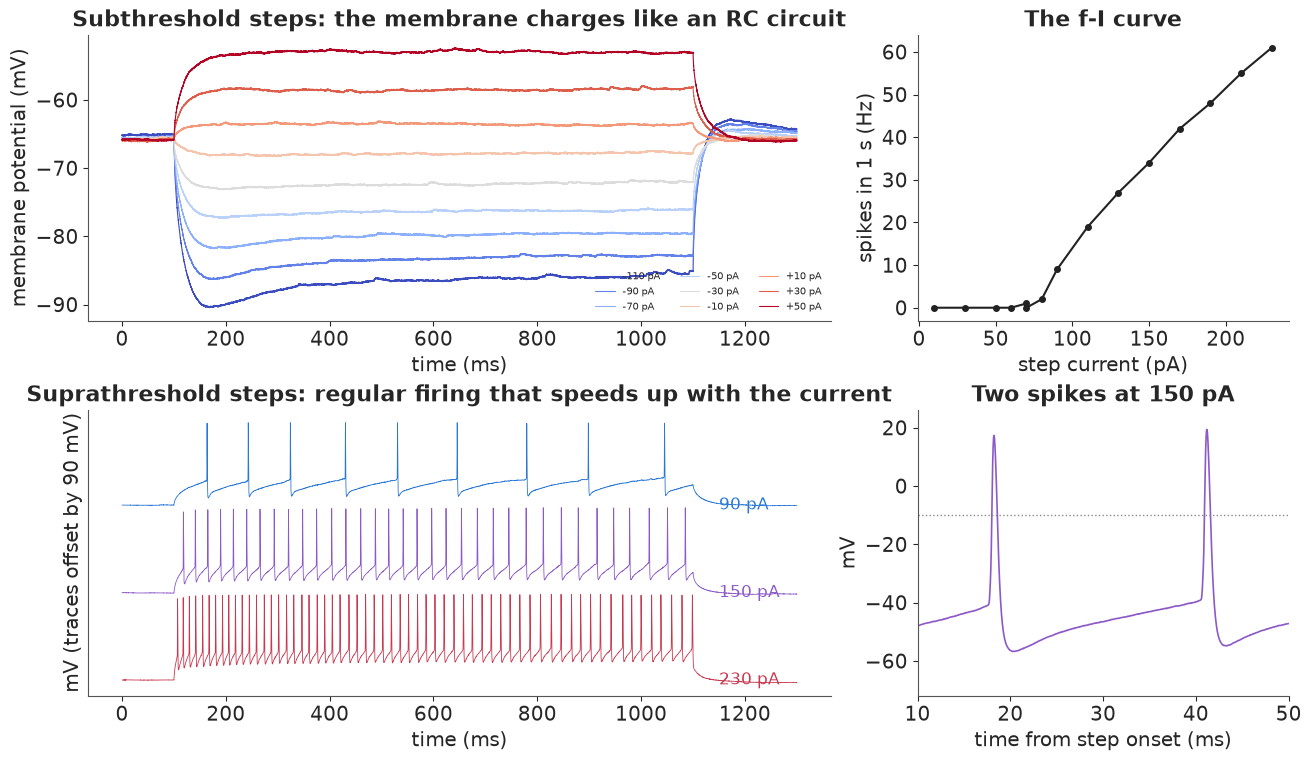

In [3]:
fig, axes = plt.subplot_mosaic([["sub", "sub", "fi"], ["sup", "sup", "zoom"]], figsize=(13, 7.5))
ax = axes["sub"]
cmap = plt.get_cmap("coolwarm")
for a in [-110, -90, -70, -50, -30, -10, 10, 30, 50]:
    ax.plot(T, sweep(a), color=cmap((a + 110) / 160), lw=0.8, label=f"{a:+.0f} pA")
ax.set(xlabel="time (ms)", ylabel="membrane potential (mV)",
       title="Subthreshold steps: the membrane charges like an RC circuit")
ax.legend(ncol=3, fontsize=7, loc="lower right")
ax = axes["sup"]
for i, a in enumerate([90, 150, 230]):
    ax.plot(T, sweep(a) + 90 * (2 - i), color=[BLUE, PURPLE, RED][i], lw=0.6)
    ax.text(1150, sweep(a)[0] + 90 * (2 - i), f"{a} pA", color=[BLUE, PURPLE, RED][i], va="center")
ax.set(xlabel="time (ms)", ylabel="mV (traces offset by 90 mV)", yticks=[],
       title="Suprathreshold steps: regular firing that speeds up with the current")
ax = axes["fi"]
ax.plot(AMP[AMP > 0], counts[AMP > 0], "o-", color=INK, ms=4)
ax.set(xlabel="step current (pA)", ylabel="spikes in 1 s (Hz)", title="The f-I curve")
ax = axes["zoom"]
ax.plot(T - T_ON, sweep(150), color=PURPLE, lw=1.2)
ax.axhline(V_LEVEL, color=GREY, ls=":", lw=1)
ax.set(xlim=(10, 50), xlabel="time from step onset (ms)", ylabel="mV", title="Two spikes at 150 pA");

**Top left**: small steps move the voltage smoothly, a first-order charging curve that settles in
a few tens of milliseconds, with a size roughly proportional to the current (about 2 mV per 10 pA,
an input resistance near 200 MΩ). Two things are not RC: the largest hyperpolarising steps
(-90, -110 pA) overshoot and **sag** back, and after the step ends they rebound above rest. That is
the signature of a hyperpolarisation-activated current ($I_h$), a channel that opens when the cell is
pushed *down*. And the depolarising steps give a little more than their share (+50 pA moves the
voltage 12.8 mV, -50 pA only 10.6 mV). **Bottom left**: above about 70-80 pA the cell fires
regularly, and faster with more current; the first spike comes earlier and the intervals lengthen
a little during the step (adaptation). **Top right**: the f-I curve rises almost linearly from 9 Hz
at 90 pA to 61 Hz at 230 pA; at 70 pA one sweep fired once and its repeat did not, so rheobase (the
smallest current that fires) is about 70-80 pA. **Bottom right**: the spikes are narrow (under 1 ms
at -10 mV), peak at about +20 mV and are followed by an AHP to about -55 mV.

## 2 · The membrane at rest: an RC circuit fitted to small current steps

Below threshold, the voltage-gated channels are nearly all closed and the membrane is a capacitor
$C$ in parallel with a leak conductance $g_L$ (a resistor $R = 1/g_L$) and a battery $E_L$:

$$C\,\frac{dV}{dt} = -g_L\,(V - E_L) + I(t).$$

For a step of size $I$ starting at $t_0$ the solution is
$V(t) = V_{\text{rest}} + R\,I\,(1 - e^{-(t - t_0)/\tau})$ with **time constant** $\tau = RC$. So
three numbers, $R$, $\tau$ and the resting potential, describe the subthreshold response, and
$C = \tau / R$ and $g_L = 1/R$ follow.

Two refinements make this fit the real recordings honestly. First, a real neuron is not a single
isopotential sphere: charge spreads from the soma into the dendrites, which adds a fast component
of a millisecond or so at the start of each step (the electrode's imperfect bridge balance adds to
it). The textbook approach (Rall's "peeling" of exponentials) is to fit a sum of exponentials and
take the **slowest** time constant as the membrane time constant; the total capacitance is then
$\tau / R$. So the response is $R\,I\,[1 - (1 - a)\,e^{-s/\tau} - a\,e^{-s/\tau_f}]$ with a fast weight
$a$ and $\tau_f < \tau$. Second, recording noise at 1 ms spacing is strongly correlated (slow
drifts, synaptic noise), so the residuals get a **stationary AR(1)** model: each residual is $\rho$
times the previous one plus fresh noise, and the first one has the stationary variance
$\sigma^2 / (1 - \rho^2)$. (A version that conditions on the first point instead drove $\rho$ to 1,
a random walk that no longer cares where the curve is, and returned nonsense; so did the
single-exponential model with independent noise, whose intervals were tiny because it treated 1,200
strongly correlated residuals as independent.) The AR(1) terms go in as a `pm.Potential`.

We fit the four smallest steps (-50, -30, -10, +10 pA) on a 1 ms grid, from 100 ms before the step
to 300 ms after its onset. Held out: the -110 pA step (to see the sag) and the +50 pA step.

In [4]:
PAS_AMPS = np.array([-50.0, -30.0, -10.0, 10.0])
SUB = 20                                              # 20 samples = 1 ms
win = T < T_ON + 300
t_pas = T[win][::SUB]
Y_PAS = np.array([sweep(a)[win][::SUB] for a in PAS_AMPS])
S_PAS = np.maximum(t_pas - T_ON, 0.0)                 # time since step onset (0 before it)


def step_response(s, tau, tau_f, a, lib=np):
    return 1.0 - (1.0 - a) * lib.exp(-s / tau) - a * lib.exp(-s / tau_f)


with pm.Model(coords={"sweep": [f"{a:+.0f} pA" for a in PAS_AMPS]}) as passive:
    v_rest = pm.Normal("v_rest", -65.0, 10.0, dims="sweep")
    R = pm.LogNormal("R", np.log(200.0), 1.0)         # input resistance, MOhm
    tau = pm.LogNormal("tau", np.log(20.0), 0.5)      # membrane (slow) time constant, ms
    tau_f = pm.LogNormal("tau_f", np.log(1.0), 0.7)   # fast (dendritic / electrode) component, ms
    a_f = pm.Beta("a_f", 2.0, 5.0)                    # its weight
    rho = pm.Uniform("rho", -1.0, 1.0)                # AR(1) coefficient of the residuals
    sigma = pm.HalfNormal("sigma", 1.0)               # innovation sd, mV
    mu = v_rest[:, None] + 1e-3 * R * PAS_AMPS[:, None] * step_response(S_PAS[None, :], tau, tau_f, a_f, pt)
    e = Y_PAS - mu
    pm.Potential("ar1", pm.logp(pm.Normal.dist(0.0, sigma / pt.sqrt(1.0 - rho**2)), e[:, 0]).sum()
                 + pm.logp(pm.Normal.dist(rho * e[:, :-1], sigma), e[:, 1:]).sum())
    pm.Deterministic("C", 1e3 * tau / R)              # pF   (ms / MOhm = nF)
    pm.Deterministic("gL", 1e3 / R)                   # nS
    t0 = time.time()
    idata_pas = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"sampled in {time.time() - t0:.0f} s, divergences: {int(idata_pas.sample_stats['diverging'].sum())}")
az.summary(idata_pas, var_names=["R", "tau", "C", "gL", "tau_f", "a_f", "rho", "sigma", "v_rest"], round_to=3)

sampled in 4 s, divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
R,228.596,1.921,225.639,231.635,1725.665,1903.741,1.001,0.047,0.044
tau,16.996,0.711,15.905,18.143,2397.705,2492.868,1.000,0.014,0.010
C,74.351,3.030,69.737,79.259,2369.594,2488.205,1.000,0.062,0.041
gL,4.375,0.037,4.317,4.432,1725.665,1903.741,1.001,0.001,0.001
tau_f,1.134,0.123,0.947,1.335,1934.446,2200.681,1.002,0.003,0.002
a_f,0.172,0.014,0.150,0.195,1724.380,2160.092,1.001,0.000,0.000
rho,0.949,0.009,0.934,0.964,2555.285,1943.162,1.001,0.000,0.000
sigma,0.054,0.001,0.052,0.055,5786.134,2610.329,1.002,0.000,0.000
v_rest[-50 pA],-65.500,0.083,-65.631,-65.370,1957.659,2341.658,1.001,0.002,0.002
v_rest[-30 pA],-65.865,0.064,-65.963,-65.764,2693.656,2789.020,1.001,0.001,0.001


-110 pA: recorded change at 150-200 ms after onset -23.3 mV, at the end of the window -21.0 mV; passive prediction -25.2 mV
+50 pA: recorded change at 150-200 ms after onset +12.8 mV, at the end of the window +13.1 mV; passive prediction +11.4 mV
R = 229 MOhm, tau = 17.0 ms, C = 74 pF, gL = 4.37 nS


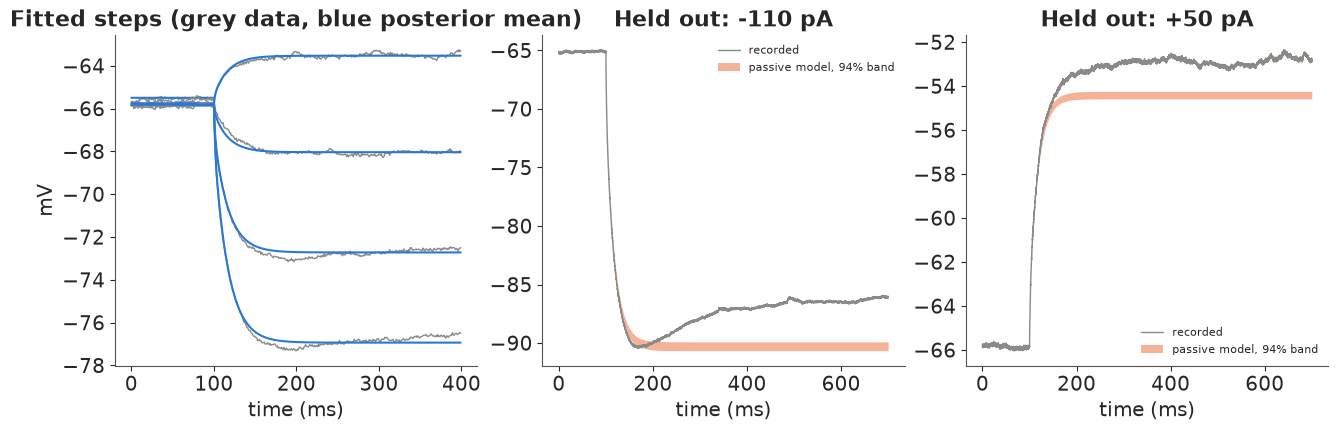

In [5]:
post_pas = az.extract(idata_pas)
pp = {k: post_pas[k].values for k in ["R", "tau", "tau_f", "a_f"]}
idx = rng.choice(pp["R"].size, 200, replace=False)


def passive_pred(s, a):
    return 1e-3 * pp["R"][idx, None] * a * step_response(s[None, :], pp["tau"][idx, None],
                                                        pp["tau_f"][idx, None], pp["a_f"][idx, None])


fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
ax = axes[0]
for j, a in enumerate(PAS_AMPS):
    ax.plot(t_pas, Y_PAS[j], color=GREY, lw=1)
    ax.plot(t_pas, (post_pas["v_rest"].values[j][idx, None] + passive_pred(S_PAS, a)).mean(0), color=BLUE, lw=1.5)
ax.set(xlabel="time (ms)", ylabel="mV", title="Fitted steps (grey data, blue posterior mean)")
for ax, a in zip(axes[1:], [-110.0, 50.0]):
    v = sweep(a)[: int((T_ON + 600) / DT)]
    tt = T[: v.size]
    pred = v[: int(T_ON / DT)].mean() + passive_pred(np.maximum(tt - T_ON, 0.0), a)  # rest from the pre-step 100 ms
    ax.plot(tt, v, color=GREY, lw=1, label="recorded")
    ax.fill_between(tt, *np.quantile(pred, [0.03, 0.97], axis=0), color=ORANGE, alpha=0.5, lw=0,
                    label="passive model, 94% band")
    ax.set(xlabel="time (ms)", title=f"Held out: {a:+.0f} pA")
    ax.legend(fontsize=8)
    print(f"{a:+.0f} pA: recorded change at 150-200 ms after onset {v[int((T_ON + 150) / DT):int((T_ON + 200) / DT)].mean() - v[:int(T_ON / DT)].mean():+.1f} mV, "
          f"at the end of the window {v[-int(50 / DT):].mean() - v[:int(T_ON / DT)].mean():+.1f} mV; "
          f"passive prediction {np.median(pred[:, -1]) - v[:int(T_ON / DT)].mean():+.1f} mV")
print(f"R = {np.median(pp['R']):.0f} MOhm, tau = {np.median(pp['tau']):.1f} ms, "
      f"C = {np.median(post_pas['C']):.0f} pF, gL = {np.median(post_pas['gL']):.2f} nS")

The sampler (nutpie) has no divergences, r_hat is at most 1.002 and every ESS is above 1,800. The
passive properties are pinned down tightly: input resistance 229 ± 2 MΩ, membrane time constant
17.0 ± 0.7 ms, hence a capacitance of 74 ± 3 pF and a leak conductance of 4.37 nS. At the usual
1 µF/cm², 74 pF is about 7,400 µm² of membrane: a small interneuron, soma plus the dendrites that
charge with it. The fast component carries 17% of the response with a time constant of 1.1 ms.
The residuals are strongly correlated ($\rho = 0.95$ at 1 ms spacing); in prototypes that ignored
this, the intervals for $R$ were four to six times narrower.

The fitted curves (left) follow the four steps. The held-out steps are the more interesting part.
At **-110 pA** the passive model predicts a drop of 25 mV that stays there; the cell does reach
that within about 70 ms, then **sags** back by about 4 mV (to -21 mV at the end of the window).
At **+50 pA** the cell goes about 1.5 mV higher than the model (+12.8 vs +11.4 mV). Neither is noise:
both are channels that a leak-only membrane does not have ($I_h$ opening below rest; a persistent
sodium current or potassium channels closing above it). The passive fit is still the right tool
for $C$ and $g_L$, because near rest these currents are small, but we now know its limits: the
single-compartment model we build next has no $I_h$ and will not reproduce the sag. Its $C$, $g_L$
and $E_L$ inherit the passive posterior as a prior.

## 3 · A conductance-based model, and how to integrate it

We use the single-compartment model of Pospischil et al. (2008), a Hodgkin-Huxley-type model
built to describe cortical neuron classes with few parameters:

$$C\,\frac{dV}{dt} = -g_L (V - E_L) - \bar g_{Na}\, m^3 h\, (V - E_{Na}) - \bar g_K\, n^4 (V - E_K) - \bar g_M\, p\, (V - E_K) + I(t).$$

Each **gating variable** $x \in \{m, h, n, p\}$ is the fraction of gates of one kind that are open, and
relaxes towards a voltage-dependent target: $dx/dt = \alpha_x(V)(1 - x) - \beta_x(V)\,x$, i.e.
$x \to x_\infty(V)$ with time constant $\tau_x(V) = 1/(\alpha_x + \beta_x)$.

| symbol | what it is | in plain terms |
|---|---|---|
| $\bar g_{Na}$, $m$, $h$ | sodium conductance, activation (fast), inactivation (slower) | the spike's upstroke; $h$ shuts the channel again |
| $\bar g_K$, $n$ | delayed-rectifier potassium conductance | brings the voltage back down; sets spike width and AHP |
| $\bar g_M$, $p$, $\tau_{\max}$ | slow, non-inactivating M-type potassium | builds up over spikes: adaptation |
| $V_T$ | shifts all Na and K rate curves | the effective spike threshold |
| $E_K$ | potassium reversal potential | how far the AHP can go |
| $C$, $g_L$, $E_L$ | capacitance, leak, leak reversal | from section 2 |

The rate functions ($\alpha$, $\beta$ for $m$, $h$, $n$; $p_\infty$ and $\tau_p$) are those of
Pospischil et al. (2008), with $E_{Na} = 53$ mV. We work with **whole-cell** conductances in nS and
capacitance in pF, so the injected current in pA enters directly.

**Integration.** The equations are stiff: $m$ changes in 0.05 ms during a spike, $p$ over hundreds
of ms. An explicit Euler step would need a tiny $\Delta t$. The standard fix in cardiac and
neural simulation is the **Rush-Larsen** method (Rush & Larsen 1978), also called exponential Euler:
over one step, freeze the voltage, and each gate obeys a *linear* ODE with an exact solution
$x_{t+\Delta t} = x_\infty + (x_t - x_\infty)\,e^{-\Delta t/\tau_x}$; with the gates frozen, $V$ also obeys
a linear ODE, $V_{t+\Delta t} = V_\infty + (V_t - V_\infty)\,e^{-\Delta t\, g_{\text{tot}}/C}$, where
$g_{\text{tot}}$ is the total conductance and $V_\infty$ the conductance-weighted mean of the
reversal potentials. This is unconditionally stable and accurate enough at $\Delta t = 0.05$ ms, the
sampling interval of the data. One second of simulated time is 20,000 steps; in Numba that takes
about 1.5 ms.

In [6]:
ENA = 53.0
T_PRE = T_ON                                  # 100 ms before the step, as in the recordings
T_SIM = T_PRE + 1000.0 + 40.0                 # simulate 40 ms past the step so late spikes complete
PARAMS = ["C", "gL", "EL", "gNa", "gK", "gM", "VT", "tau_max", "EK"]


@nb.njit(fastmath=True)
def _rates(V, VT):
    """Pospischil et al. (2008) rate functions (1/ms); the removable 0/0 points are patched."""
    x = V - VT - 13.0
    am = 1.28 if abs(x) < 1e-6 else -0.32 * x / (np.exp(-x / 4.0) - 1.0)
    x = V - VT - 40.0
    bm = 1.4 if abs(x) < 1e-6 else 0.28 * x / (np.exp(x / 5.0) - 1.0)
    ah = 0.128 * np.exp(-(V - VT - 17.0) / 18.0)
    bh = 4.0 / (1.0 + np.exp(-(V - VT - 40.0) / 5.0))
    x = V - VT - 15.0
    an = 0.16 if abs(x) < 1e-6 else -0.032 * x / (np.exp(-x / 5.0) - 1.0)
    bn = 0.5 * np.exp(-(V - VT - 10.0) / 40.0)
    return am, bm, ah, bh, an, bn


@nb.njit(fastmath=True)
def simulate(theta, amp, t_total, gates=False):
    """Rush-Larsen integration. theta = C (pF), gL (nS), EL (mV), gNa, gK, gM (nS), VT (mV),
    tau_max (ms), EK (mV); a step of `amp` pA from T_PRE for 1000 ms. Starts with the gates at
    their steady state at V = EL. Returns V (and m, h, n, p if gates=True) every DT."""
    C, gL, EL, gNa, gK, gM, VT, tmax, EK = theta
    n_steps = int(t_total / DT)
    V = EL
    am, bm, ah, bh, an, bn = _rates(V, VT)
    m, h, n = am / (am + bm), ah / (ah + bh), an / (an + bn)
    p = 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))
    out = np.empty((n_steps, 5 if gates else 1))
    for k in range(n_steps):
        t = k * DT
        I = amp if (t >= T_PRE and t < T_PRE + 1000.0) else 0.0
        am, bm, ah, bh, an, bn = _rates(V, VT)
        sm, sh, sn = am + bm, ah + bh, an + bn
        m = am / sm + (m - am / sm) * np.exp(-DT * sm)
        h = ah / sh + (h - ah / sh) * np.exp(-DT * sh)
        n = an / sn + (n - an / sn) * np.exp(-DT * sn)
        pinf = 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))
        tp = tmax / (3.3 * np.exp((V + 35.0) / 20.0) + np.exp(-(V + 35.0) / 20.0))
        p = pinf + (p - pinf) * np.exp(-DT / tp)
        gna = gNa * m * m * m * h
        gk = gK * n * n * n * n + gM * p
        gtot = gL + gna + gk
        vinf = (gL * EL + gna * ENA + gk * EK + I) / gtot
        V = vinf + (V - vinf) * np.exp(-DT * gtot / C)
        out[k, 0] = V
        if gates:
            out[k, 1] = m
            out[k, 2] = h
            out[k, 3] = n
            out[k, 4] = p
    return out


# A reference parameter set: roughly the posterior mean of the feature fit in section 5
THETA_REF = np.array([79.0, 4.37, -65.1, 690.0, 220.0, 4.7, -56.7, 900.0, -94.0])
sim_ref = simulate(THETA_REF, 150.0, T_PRE + 1000.0, True)
simulate(THETA_REF, 150.0, T_PRE + 1000.0)             # compile the gates=False version
t0 = time.time()
for _ in range(10):
    simulate(THETA_REF, 150.0, T_PRE + 1000.0)
print(f"one 1.1 s simulation: {(time.time() - t0) / 10 * 1e3:.1f} ms")

one 1.1 s simulation: 1.7 ms


p (M-current gate): 0.045 at rest, 0.193 after 75 ms, 0.357 at the end of the step


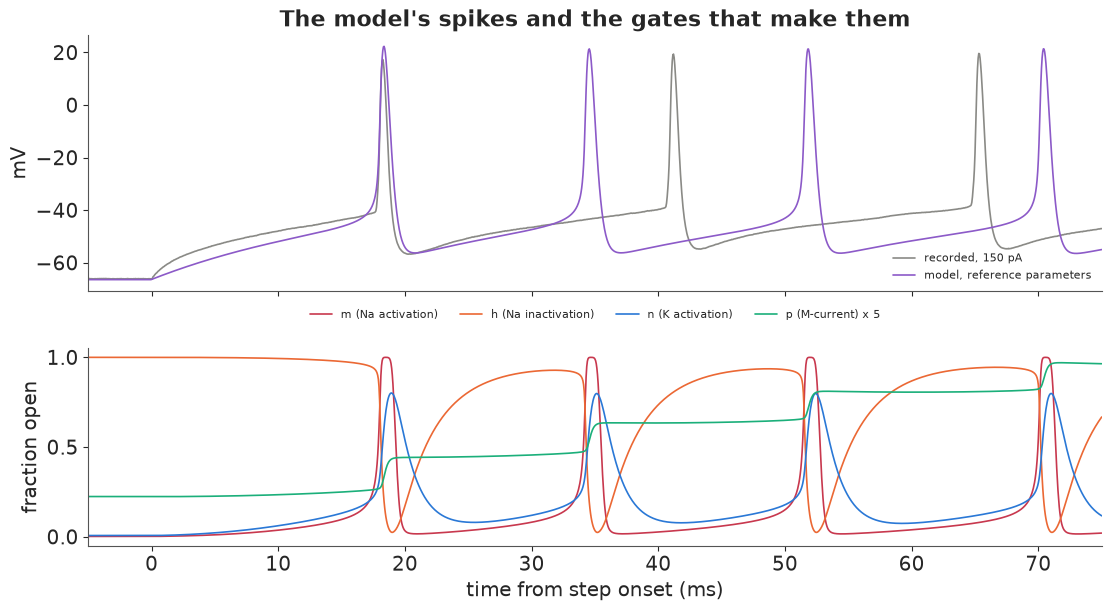

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, height_ratios=[1.3, 1])
tt = T[: sim_ref.shape[0]] - T_ON
ax = axes[0]
ax.plot(tt, sweep(150)[: tt.size], color=GREY, lw=1.2, label="recorded, 150 pA")
ax.plot(tt, sim_ref[:, 0], color=PURPLE, lw=1.2, label="model, reference parameters")
ax.set(ylabel="mV", xlim=(-5, 75), title="The model's spikes and the gates that make them")
ax.legend(fontsize=8, loc="lower right")
ax = axes[1]
for j, (lab, c) in enumerate(zip(["m (Na activation)", "h (Na inactivation)", "n (K activation)",
                                  "p (M-current) x 5"], [RED, ORANGE, BLUE, AQUA])):
    ax.plot(tt, sim_ref[:, j + 1] * (5 if j == 3 else 1), color=c, lw=1.2, label=lab)
ax.set(xlabel="time from step onset (ms)", ylabel="fraction open", ylim=(-0.05, 1.05))
ax.legend(fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.25), frameon=False)
print(f"p (M-current gate): {sim_ref[int(T_ON / DT) - 1, 4]:.3f} at rest, {sim_ref[int((T_ON + 75) / DT), 4]:.3f} after 75 ms, "
      f"{sim_ref[-1, 4]:.3f} at the end of the step");

The model makes spikes of the right height and width, and its first spike comes at the right
time, but the next ones come too early: its first intervals are about 17 ms against the cell's 23-24
ms. (Over the whole second this parameter set still fires about as many spikes as the cell,
because its adaptation is stronger; we come back to that in section 7.) The gates show the
mechanism. When the voltage reaches threshold, $m$ (red) jumps from near 0 to near 1 in a fraction
of a millisecond: sodium rushes in. $h$ (orange) falls a little later and switches the sodium
channels off; $n$ (blue) rises and potassium pulls the voltage down into the AHP. Between spikes
$h$ recovers and $n$ decays, and the injected current charges the membrane to the next threshold
crossing. $p$ (green, multiplied by 5) steps up with every spike and barely decays in between: it
goes from 0.045 at rest to 0.19 after 75 ms and 0.36 by the end of the step. That slowly growing
potassium current is what lengthens the later intervals.

## 4 · Why matching the voltage trace fails

The obvious likelihood treats the recorded trace as the model trace plus noise:
$V^{\text{obs}}_t \sim \text{Normal}(V_t(\theta), \sigma)$. Below threshold this works (section 2). With
spikes it breaks. A spike is 1 ms wide and the intervals are 20-30 ms. Change a conductance by a
few percent and the spike train shifts in time; once a model spike is half a millisecond from the
recorded one, the residual contains two full spikes instead of none. The likelihood then depends
on *how many spikes happen to line up*, which jumps up and down as the parameter changes.

Below: a one-dimensional profile over $\bar g_K$ (every other parameter at the reference values),
comparing the Gaussian trace log-likelihood over the full 150 pA sweep ($\sigma$ = 2 mV, every 0.25 ms)
with the feature-based log-likelihood of section 5.

In [8]:
@nb.njit
def detect(v, dt, t_on, t_dur):
    """Spikes = upward crossings of V_LEVEL that start during the step. Returns spike times (ms from
    step onset), peaks, troughs (minimum in the 30 ms after the down-crossing, or until the next
    spike) and widths (time above V_LEVEL)."""
    nmax = 400
    ts, pk, tr, wd = np.zeros(nmax), np.zeros(nmax), np.zeros(nmax), np.zeros(nmax)
    ns, k, n = 0, 1, v.shape[0]
    while k < n and ns < nmax:
        if v[k] > V_LEVEL and v[k - 1] <= V_LEVEL:
            j, vmax = k, v[k]
            while j < n and v[j] >= V_LEVEL:
                vmax = max(vmax, v[j])
                j += 1
            if k * dt >= t_on and k * dt < t_on + t_dur:
                ts[ns], pk[ns], wd[ns] = k * dt - t_on, vmax, (j - k) * dt
                vmin, q = 1e9, j
                while q < n and (q - j) * dt < 30.0 and v[q] <= V_LEVEL:
                    vmin = min(vmin, v[q])
                    q += 1
                tr[ns] = vmin if vmin < 1e8 else v[n - 1]    # a spike at the very end of the record
                ns += 1
            k = j
        k += 1
    return ts[:ns], pk[:ns], tr[:ns], wd[:ns]


@nb.njit
def summarize(v, dt):
    """Six spike features of one 1 s step: spike count, log first-spike latency (ms), mean peak (mV),
    mean trough (mV), mean width at -10 mV (ms), log(last ISI / first ISI). Without spikes: count 0,
    latency 1000 ms, and the maximum voltage reached (minus 20 mV) stands in for the trough."""
    ts, pk, tr, wd = detect(v, dt, T_ON, 1000.0)
    f = np.zeros(6)
    n = ts.shape[0]
    if n == 0:
        f[1] = np.log(1000.0)
        f[2] = V_LEVEL
        f[3] = v[int(T_ON / dt):int((T_ON + 1000.0) / dt)].max() - 20.0
        return f
    f[0], f[1] = n, np.log(max(ts[0], 0.5))
    f[2], f[3], f[4] = pk.mean(), tr.mean(), wd.mean()
    if n >= 3:
        f[5] = np.log((ts[n - 1] - ts[n - 2]) / (ts[1] - ts[0]))
    return f


@nb.njit
def features(theta, amps):
    out = np.zeros((amps.shape[0], 6))
    for i in range(amps.shape[0]):
        out[i] = summarize(simulate(theta, amps[i], T_SIM)[:, 0], DT)
    return out


FEATS = ["spike count", "log latency", "peak (mV)", "trough (mV)", "width (ms)", "log ISI ratio"]
FEAT_SD = np.array([2.0, 0.15, 3.0, 2.0, 0.1, 0.15])
FIT_AMPS = np.array([90.0, 150.0, 210.0])
F_OBS = np.array([summarize(sweep(a), DT) for a in FIT_AMPS])


def feature_loglik(theta):
    return -0.5 * np.sum(((features(theta, FIT_AMPS) - F_OBS) / FEAT_SD) ** 2)


v150 = sweep(150)[: int((T_PRE + 1000) / DT)]
gk_mult = np.exp(np.linspace(np.log(0.6), np.log(1.6), 241))
ll_trace, ll_feat = np.zeros(gk_mult.size), np.zeros(gk_mult.size)
t0 = time.time()
for i, mlt in enumerate(gk_mult):
    th = THETA_REF.copy()
    th[4] *= mlt
    v = simulate(th, 150.0, T_PRE + 1000.0)[:, 0]
    ll_trace[i] = stats.norm.logpdf(v150[::5], v[::5], 2.0).sum()
    ll_feat[i] = feature_loglik(th)
print(f"{gk_mult.size} x 4 simulations in {time.time() - t0:.1f} s")
n_local = np.sum((ll_trace[1:-1] > ll_trace[:-2]) & (ll_trace[1:-1] > ll_trace[2:]))
print(f"trace log-likelihood: {n_local} local maxima on the grid, range {ll_trace.min():.0f} to {ll_trace.max():.0f}")
print(f"feature log-likelihood: maximum at gK x {gk_mult[ll_feat.argmax()]:.2f}")

241 x 4 simulations in 3.5 s
trace log-likelihood: 12 local maxima on the grid, range -155511 to -122350
feature log-likelihood: maximum at gK x 1.01


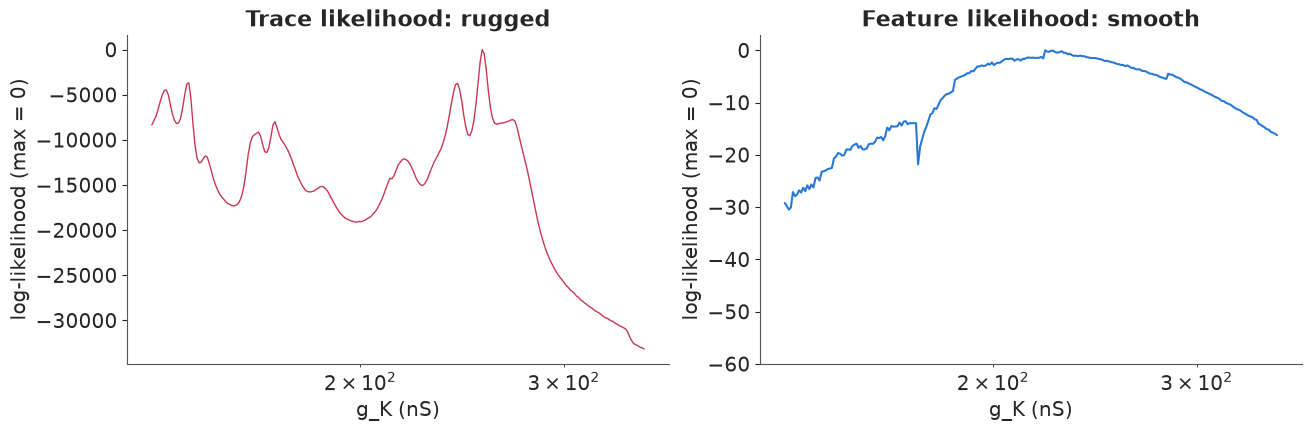

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.plot(THETA_REF[4] * gk_mult, ll_trace - ll_trace.max(), color=RED, lw=1, label="voltage trace")
ax.set(xscale="log", xlabel="g_K (nS)", ylabel="log-likelihood (max = 0)",
       title="Trace likelihood: rugged")
ax2 = axes[1]
ax2.plot(THETA_REF[4] * gk_mult, ll_feat - ll_feat.max(), color=BLUE, lw=1.5, label="spike features")
ax2.set(xscale="log", xlabel="g_K (nS)", ylabel="log-likelihood (max = 0)",
        title="Feature likelihood: smooth", ylim=(-60, 3));

The trace log-likelihood (left) has a dozen local maxima on this grid of 241 points and varies over
more than 30,000 log-units; most of that variation says only whether spikes happen to coincide. A
gradient-based sampler started anywhere on this landscape climbs the nearest peak. The feature
log-likelihood (right, same parameter, a scale 500 times smaller) is a single broad bump with its
maximum within 1% of the reference $\bar g_K$. It is not perfectly smooth: it has small steps
wherever a spike count changes by one (worth little against a tolerance of 2 spikes) and one notch
near 165 nS, but nothing that would trap a sampler.

To see what that does to MCMC, here is trace matching done *inside PyMC*: the same Rush-Larsen
step written in PyTensor and iterated with `scan` over the first 80 ms of the 150 pA step
(1,600 steps, three spikes), with $\log \bar g_{Na}$, $\log \bar g_K$ and $V_T$ free and the rest fixed.
Gradients flow through `scan`, so NUTS can run. Four chains, 300 warm-up and 300 draws each.

In [10]:
N_WIN = int(80 / DT)
v_win = sweep(150)[int(T_ON / DT):int(T_ON / DT) + N_WIN]
C0, GL0, EL0, _, _, GM0, _, TMAX0, EK0 = THETA_REF


def rates_pt(V, VT):
    x = V - VT - 13.0
    am = -0.32 * x / pt.expm1(-x / 4.0)
    x = V - VT - 40.0
    bm = 0.28 * x / pt.expm1(x / 5.0)
    ah = 0.128 * pt.exp(-(V - VT - 17.0) / 18.0)
    bh = 4.0 / (1.0 + pt.exp(-(V - VT - 40.0) / 5.0))
    x = V - VT - 15.0
    an = -0.032 * x / pt.expm1(-x / 5.0)
    bn = 0.5 * pt.exp(-(V - VT - 10.0) / 40.0)
    return am, bm, ah, bh, an, bn


def rush_larsen_step(V, m, h, n, p, gNa, gK, VT):
    am, bm, ah, bh, an, bn = rates_pt(V, VT)
    sm, sh, sn = am + bm, ah + bh, an + bn
    m = am / sm + (m - am / sm) * pt.exp(-DT * sm)
    h = ah / sh + (h - ah / sh) * pt.exp(-DT * sh)
    n = an / sn + (n - an / sn) * pt.exp(-DT * sn)
    pinf = pt.sigmoid((V + 35.0) / 10.0)
    tp = TMAX0 / (3.3 * pt.exp((V + 35.0) / 20.0) + pt.exp(-(V + 35.0) / 20.0))
    p = pinf + (p - pinf) * pt.exp(-DT / tp)
    gna, gk = gNa * m**3 * h, gK * n**4 + GM0 * p
    gtot = GL0 + gna + gk
    vinf = (GL0 * EL0 + gna * ENA + gk * EK0 + 150.0) / gtot
    return vinf + (V - vinf) * pt.exp(-DT * gtot / C0), m, h, n, p


with pm.Model() as trace_model:
    log_gNa = pm.Normal("log_gNa", np.log(2000.0), 1.0)
    log_gK = pm.Normal("log_gK", np.log(400.0), 1.0)
    VT = pm.Normal("VT", -60.0, 5.0)
    V0 = pt.as_tensor(v_win[0])
    am, bm, ah, bh, an, bn = rates_pt(V0, VT)
    init = [V0, am / (am + bm), ah / (ah + bh), an / (an + bn), pt.sigmoid((V0 + 35.0) / 10.0)]
    states = pytensor.scan(rush_larsen_step, outputs_info=init, non_sequences=[pt.exp(log_gNa), pt.exp(log_gK), VT],
                           n_steps=N_WIN - 1, return_updates=False)
    v_model = pm.Deterministic("v_model", pt.concatenate([V0[None], states[0]])[::5])
    pm.Normal("v", v_model, 2.0, observed=v_win[::5])
    t0 = time.time()
    idata_tr = pm.sample(tune=300, draws=300, random_seed=RANDOM_SEED, progressbar=False)
print(f"sampled in {time.time() - t0:.0f} s, divergences: {int(idata_tr.sample_stats['diverging'].sum())}")
print(az.summary(idata_tr, var_names=["log_gNa", "log_gK", "VT"], round_to=3)[["mean", "sd", "ess_bulk", "r_hat"]])
for c in range(4):
    p = idata_tr.posterior
    print(f"chain {c}: gNa = {np.exp(p['log_gNa'].values[c].mean()):7.0f} nS, gK = "
          f"{np.exp(p['log_gK'].values[c].mean()):5.0f} nS, VT = {p['VT'].values[c].mean():6.1f} mV, "
          f"mean log-lik = {idata_tr.sample_stats['logp'].values[c].mean():8.0f}")

sampled in 44 s, divergences: 0
           mean     sd  ess_bulk  r_hat
log_gNa   5.637  1.244     7.464  1.554
log_gK    5.558  0.007   433.309  1.270
VT      -61.753  0.641     7.480  1.557
chain 0: gNa =     137 nS, gK =   259 nS, VT =  -62.1 mV, mean log-lik =    -4012
chain 1: gNa =     137 nS, gK =   259 nS, VT =  -62.1 mV, mean log-lik =    -4012
chain 2: gNa =    2422 nS, gK =   260 nS, VT =  -60.6 mV, mean log-lik =   -23407
chain 3: gNa =     137 nS, gK =   259 nS, VT =  -62.1 mV, mean log-lik =    -4012


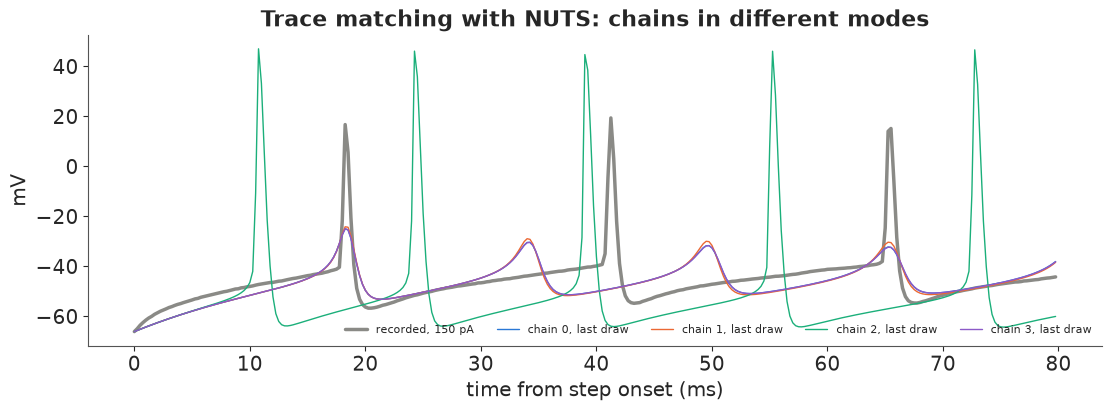

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
tw = np.arange(N_WIN)[::5] * DT
ax.plot(tw, v_win[::5], color=GREY, lw=2.5, label="recorded, 150 pA")
for c, col in enumerate([BLUE, ORANGE, AQUA, PURPLE]):
    ax.plot(tw, idata_tr.posterior["v_model"].values[c, -1], color=col, lw=1, label=f"chain {c}, last draw")
ax.set(xlabel="time from step onset (ms)", ylabel="mV", title="Trace matching with NUTS: chains in different modes")
ax.legend(fontsize=8, ncol=5, loc="lower right");

The chains disagree about the answer, and the diagnostics report it only through r_hat (about 1.55)
and a bulk ESS of 7, with **zero divergences**: every chain samples happily around its own local
optimum. The traces show what the modes are. Three chains settled on $\bar g_{Na} \approx 140$ nS, a
model that makes **no real spikes at all**, only small bumps to about -30 mV that roughly track the
recorded rhythm. The fourth found $\bar g_{Na} \approx 2{,}400$ nS and fires proper, too-tall spikes,
five instead of three, at the wrong times. And the likelihood *prefers* the spikeless model (mean
log-likelihood about -4,000 against -23,000): a missing spike costs the squared error of one spike, a
misplaced spike costs it twice (once where the model spikes, once where the cell does). This is the
general failure of pointwise matching for oscillating or spiking signals, and more warm-up would not
help (E46 found the same for a chaotic map). This window has only three spikes; a full second has
34, and the comb in the profile above gets finer.

There are cures: fit the spike *times* (a point-process likelihood), align spikes before
comparing shapes, or use multiple shooting (E47). The common practice, used below, is to reduce each
sweep to **features** that vary smoothly with the parameters.

## 5 · A likelihood on spike features, sampled with SMC

For each fitted current step we compute six features (the `summarize` function above): the
**spike count** in the 1 s step (the firing rate), the **log latency** of the first spike, mean
**spike peak**, mean **AHP trough**, mean **spike width** at -10 mV, and an **adaptation** index,
the log ratio of the last to the first interspike interval. We fit three steps (90, 150, 210 pA)
and hold out the other nine steps from 60 pA up (including the repeat at 70 pA) for section 7.

The likelihood is Gaussian on the features, $f^{\text{obs}}_{jk} \sim \text{Normal}(f_{jk}(\theta), s_k)$,
with scales $s_k$ = 2 spikes, 0.15 (15% on latency), 3 mV, 2 mV, 0.1 ms, 0.15. These are
**tolerances**, not measurement errors. Repeated sweeps differ by a few spikes (the Allen metadata
for this cell lists 2 s repeats at 110 pA with 33, 37 and 37 spikes), but the larger part is model
error: a one-compartment model with three channels will not reproduce this cell
exactly, and the scales say how closely we ask it to. The posterior width scales with them
(exercise 1).

The features are not differentiable functions of $\theta$ (spike counts are integers, thresholds
are crossings), so NUTS is out. PyMC's **`pm.Simulator`** takes any Python function that returns
simulated summaries; with `distance="gaussian"`, `epsilon=1` and standardised features, its
"ABC kernel" is exactly our Gaussian feature likelihood. **Sequential Monte Carlo**
(`pm.sample_smc`) samples it by tempering from the prior to the posterior through a sequence of
intermediate distributions, moving a population of particles with Metropolis steps; it needs only
likelihood evaluations. Each evaluation is three 1.1 s simulations, about 5 ms.

**Priors.** $C$, $g_L$ and $E_L$ come from the passive posterior (log-normal / normal with its mean
and sd). The conductances are log-normal around typical values of the Pospischil et al. (2008)
cortical models scaled to about 75 pF of membrane (50 mS/cm² of Na, 5 mS/cm² of K, 0.07 mS/cm² of M),
with a factor $e$ of spread; $V_T \sim \text{Normal}(-60, 5)$ mV; $E_K \sim \text{Normal}(-95, 7)$ mV;
$\tau_{\max} \sim \text{LogNormal}(\log 1000, 0.7)$ ms.

In [12]:
log_C, log_gL = np.log(post_pas["C"].values), np.log(post_pas["gL"].values)
vr_all = post_pas["v_rest"].values.mean(axis=0)
PRIOR = {  # name: (distribution, location, scale); lognormal ones on the log scale
    "C": ("lognormal", log_C.mean(), log_C.std()),
    "gL": ("lognormal", log_gL.mean(), log_gL.std()),
    "EL": ("normal", vr_all.mean(), 1.0),
    "gNa": ("lognormal", np.log(4000.0), 1.0),
    "gK": ("lognormal", np.log(400.0), 1.0),
    "gM": ("lognormal", np.log(5.0), 1.0),
    "VT": ("normal", -60.0, 5.0),
    "tau_max": ("lognormal", np.log(1000.0), 0.7),
    "EK": ("normal", -95.0, 7.0),
}
for k, (d, loc, sc) in PRIOR.items():
    print(f"{k:8s} {d:9s} median {np.exp(loc) if d == 'lognormal' else loc:8.2f}, sd {sc:.3f}")


def simulator(rng, C, gL, EL, gNa, gK, gM, VT, tau_max, EK, size=None):
    th = np.array([C[0], gL[0], EL[0], gNa[0], gK[0], gM[0], VT[0], tau_max[0], EK[0]], dtype=float)
    return (features(th, FIT_AMPS) / FEAT_SD).ravel()


with pm.Model() as feature_model:
    theta = [pm.LogNormal(k, loc, sc) if d == "lognormal" else pm.Normal(k, loc, sc)
             for k, (d, loc, sc) in PRIOR.items()]
    pm.Simulator("features", simulator, *theta, epsilon=1.0, distance="gaussian", sum_stat="identity",
                 observed=(F_OBS / FEAT_SD).ravel())
    t0 = time.time()
    idata_smc = pm.sample_smc(draws=500, chains=2, cores=2, random_seed=RANDOM_SEED, progressbar=False)
print(f"SMC: {time.time() - t0:.0f} s")
for c in range(2):
    beta = idata_smc.sample_stats["beta"].values[c]
    acc = idata_smc.sample_stats["accept_rate"].values[c]
    print(f"chain {c}: {len(beta)} tempering stages, acceptance first/last stage {acc[0]:.2f} / {acc[-1]:.2f}")
summ_smc = az.summary(idata_smc, var_names=PARAMS, round_to=3)
summ_smc[["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]]

C        lognormal median    74.29, sd 0.041
gL       lognormal median     4.37, sd 0.008
EL       normal    median   -65.73, sd 1.000
gNa      lognormal median  4000.00, sd 1.000
gK       lognormal median   400.00, sd 1.000
gM       lognormal median     5.00, sd 1.000
VT       normal    median   -60.00, sd 5.000
tau_max  lognormal median  1000.00, sd 0.700
EK       normal    median   -95.00, sd 7.000


SMC: 164 s
chain 0: 10 tempering stages, acceptance first/last stage 0.73 / 0.13
chain 1: 10 tempering stages, acceptance first/last stage 0.72 / 0.13


,mean,sd,eti89_lb,eti89_ub,ess_bulk,r_hat
C,79.026,2.772,74.576,83.927,999.769,1.001
gL,4.369,0.036,4.315,4.428,519.775,1.010
EL,-64.756,0.932,-66.268,-63.260,635.218,1.004
gNa,682.741,49.554,610.252,767.040,741.609,1.004
gK,222.108,42.935,165.356,297.613,921.306,1.001
gM,4.682,1.019,3.331,6.439,539.041,1.003
VT,-56.432,1.528,-58.661,-54.018,649.546,1.000
tau_max,886.378,697.329,250.031,2112.834,640.243,1.000
EK,-93.826,5.527,-102.360,-85.114,499.656,1.001


share of draws with tau_max < 500 ms, per SMC chain: 0.50, 0.50
  tau_max < 500 ms: median tau_max   292 ms, VT -57.7 mV, gM 4.9 nS, gK 198 nS
  tau_max > 500 ms: median tau_max  1351 ms, VT -55.2 mV, gM 4.2 nS, gK 236 nS


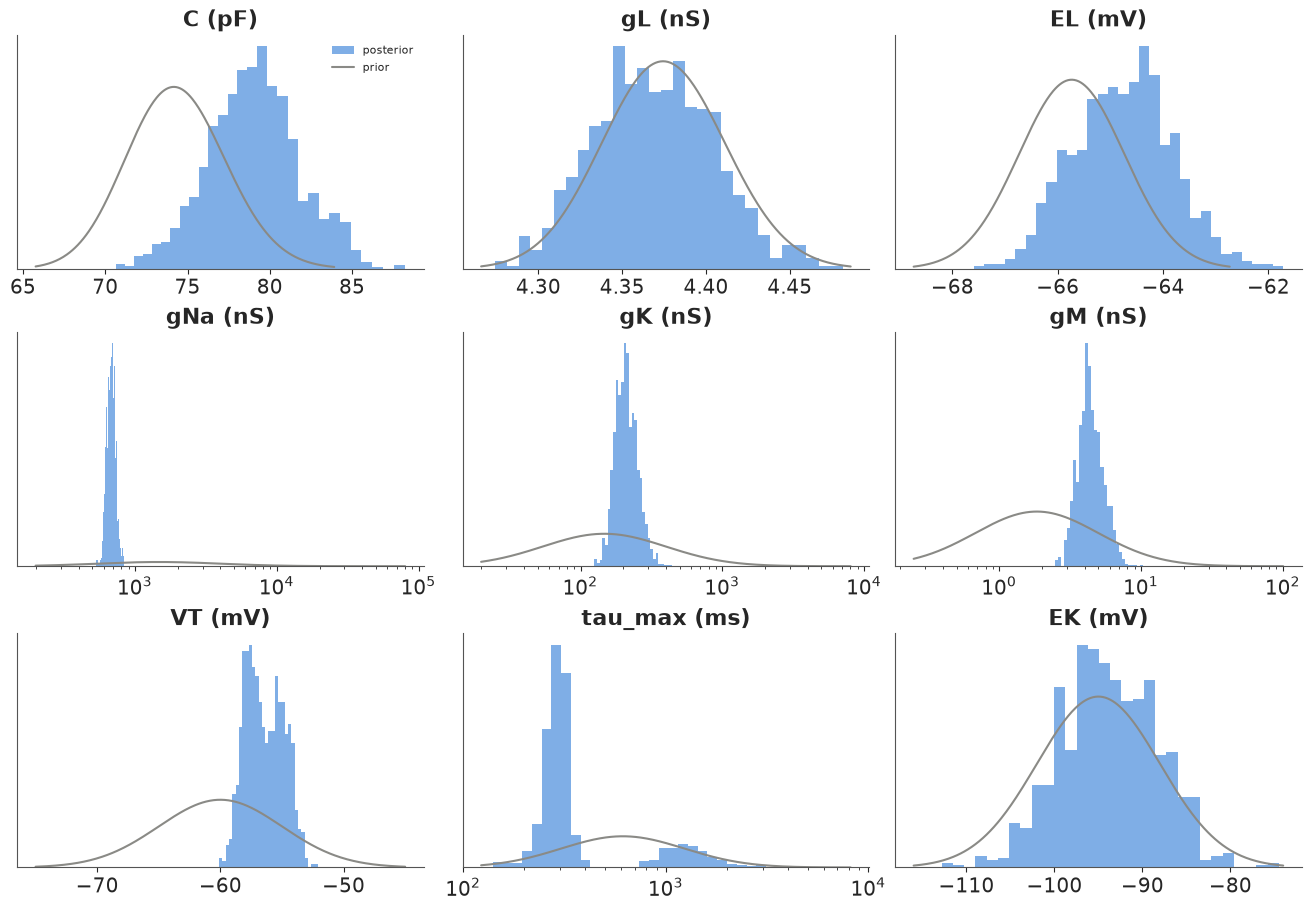

In [13]:
post = az.extract(idata_smc)
draws = np.column_stack([post[k].values for k in PARAMS])            # (1000, 9)
units = ["pF", "nS", "mV", "nS", "nS", "nS", "mV", "ms", "mV"]
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, k, u, j in zip(axes.ravel(), PARAMS, units, range(9)):
    d, loc, sc = PRIOR[k]
    x = draws[:, j]
    if d == "lognormal":
        grid = np.exp(np.linspace(loc - 3 * sc, loc + 3 * sc, 300))
        dens = stats.lognorm.pdf(grid, sc, scale=np.exp(loc))
        bins = np.exp(np.linspace(np.log(x.min()), np.log(x.max()), 30))
        if sc > 0.3:
            ax.set_xscale("log")
    else:
        grid = np.linspace(loc - 3 * sc, loc + 3 * sc, 300)
        dens = stats.norm.pdf(grid, loc, sc)
        bins = 30
    ax.hist(x, bins=bins, density=True, color=BLUE, alpha=0.6, label="posterior")
    ax.plot(grid, dens, color=GREY, lw=1.5, label="prior")
    ax.set(title=f"{k} ({u})", yticks=[])
axes[0, 0].legend(fontsize=8)
short = draws[:, PARAMS.index("tau_max")] < 500
print("share of draws with tau_max < 500 ms, per SMC chain: "
      + ", ".join(f"{np.mean(idata_smc.posterior['tau_max'].values[c] < 500):.2f}" for c in range(2)))
for lab, msk in [("tau_max < 500 ms", short), ("tau_max > 500 ms", ~short)]:
    print(f"  {lab}: median tau_max {np.median(draws[msk, 7]):5.0f} ms, VT {np.median(draws[msk, 6]):.1f} mV, "
          f"gM {np.median(draws[msk, 5]):.1f} nS, gK {np.median(draws[msk, 4]):.0f} nS")

Both SMC chains ran 10 tempering stages and ended at a final-stage acceptance of 13%, well above
the ~2% at which an SMC population degenerates (AUTHORING's E14 note); r_hat is at most 1.01 and
the bulk ESS is 500-1,000 for every parameter. SMC's "chains" are independent particle
populations, so their agreement is a real check.

What the spikes taught us (blue against the grey priors; the x axes of the widely spread
log-normal parameters are logarithmic):

- **$\bar g_{Na}$ is sharply identified**, to about 7% (683 ± 50 nS): the spike height pins it.
- **$\bar g_K$ and $\bar g_M$** are learned to about 20% (222 ± 43 and 4.7 ± 1.0 nS); the prior spread was
  a factor of $e$.
- **$V_T$ and $\tau_{\max}$ have a bimodal posterior.** There are two ways to produce this cell's
  adaptation: a fast M-current ($\tau_{\max} \approx 300$ ms) with a lower threshold shift
  ($V_T \approx -58$ mV), or a slow one ($\tau_{\max}$ of 1-2 s) with $V_T \approx -55$ mV (the printed
  medians). Both SMC chains found both modes in similar proportions, which is what SMC's particle
  population is good at; a gradient sampler started in one would likely have stayed there.
- **$E_K$ is barely learned** (sd 5.5 mV against the prior's 7).
- **$C$, $g_L$ and $E_L$** stay near the passive-fit priors, except that $C$ moves up from 74 to
  79 pF, about 1.5 prior sds: the spike timing wants a slightly larger capacitance than the
  subthreshold charging curve gave.

Note the posterior's sodium conductance, about 680 nS, is **far below** the prior median of
4,000 nS (Pospischil's 50 mS/cm² scaled by area). A one-compartment model with the Na kinetics of
another cell type and spikes that only reach +20 mV wants much less sodium. That is a statement
about this model, not a measurement of channel density in the cell.

How well are the fitted features reproduced? We simulate 200 posterior draws.

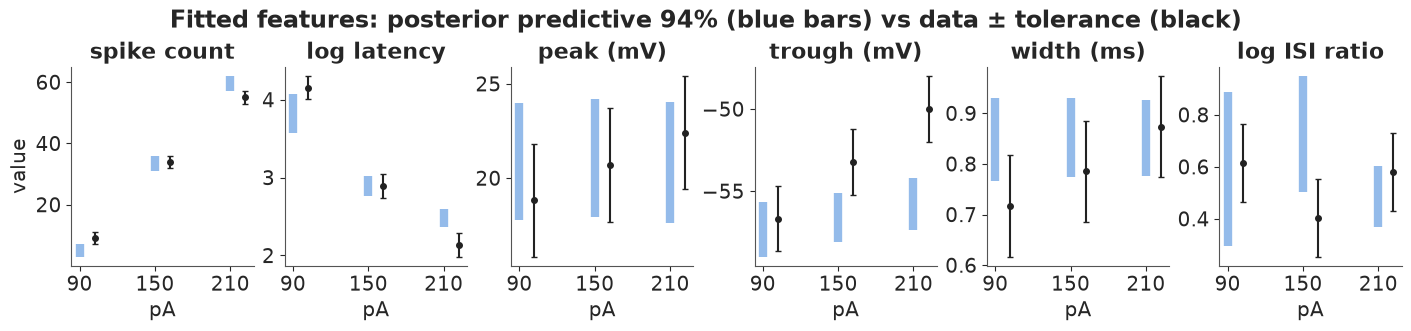

In [14]:
sub_idx = rng.choice(draws.shape[0], 200, replace=False)
F_pp = np.array([features(draws[i], FIT_AMPS) for i in sub_idx])      # (200, 3, 6)
fig, axes = plt.subplots(1, 6, figsize=(14, 3.2))
for k, ax in enumerate(axes):
    for j, a in enumerate(FIT_AMPS):
        lo, hi = np.quantile(F_pp[:, j, k], [0.03, 0.97])
        ax.plot([a, a], [lo, hi], color=BLUE, lw=6, alpha=0.5, solid_capstyle="butt")
        ax.errorbar(a + 12, F_OBS[j, k], yerr=FEAT_SD[k], fmt="o", color=INK, ms=4, capsize=2)
    ax.set(title=FEATS[k], xlabel="pA", xticks=FIT_AMPS)
axes[0].set_ylabel("value")
fig.suptitle("Fitted features: posterior predictive 94% (blue bars) vs data ± tolerance (black)");

Peak height, spike width, latency and spike count sit within their tolerances; the misses are
systematic and belong to the model. The model's spike count rises more steeply with current than the
cell's (3-8 spikes at 90 pA against 9; 57-62 at 210 pA against 55). Its adaptation index at 150 pA
(0.5-0.95) is larger than the cell's 0.40: the model adapts more. And the recorded AHP troughs get
shallower as the current grows (-57 to -50 mV) while the model's stay near -57 to -55 mV. A richer
model (another potassium channel, a dendrite) would be needed to fix these; the feature likelihood
makes such misfits visible one feature at a time, which the trace likelihood never could.

## 6 · Sloppiness: what the spikes pin down and what they do not

Marginal posteriors hide the most important structure: **combinations** of parameters. Goldman et
al. (2001) and Prinz, Bucher & Marder (2004) showed that very different sets of conductances can
produce nearly the same activity, and Marder & Goaillard (2006) argued that real neurons of one type
vary this way; Gutenkunst et al. (2007) found that most models in systems biology are "sloppy":
their behaviour is controlled by a few stiff parameter combinations while many others barely matter.

To see this in our posterior, put every parameter on its unconstrained scale (log for the positive
ones), divide by its prior sd, and eigen-decompose the posterior covariance. In these units the prior
has covariance $I$. An eigenvalue $\lambda$ says how much the data shrank the posterior along that
direction: $\sqrt{\lambda} = 1$ means nothing was learned, $\sqrt\lambda = 0.1$ means the data made it
ten times narrower than the prior.

In [15]:
is_log = np.array([PRIOR[k][0] == "lognormal" for k in PARAMS])
prior_loc = np.array([PRIOR[k][1] for k in PARAMS])
prior_sd = np.array([PRIOR[k][2] for k in PARAMS])
U = draws.copy()
U[:, is_log] = np.log(draws[:, is_log])                              # unconstrained scale
Z = (U - prior_loc) / prior_sd
cov = np.cov(Z.T)
lam, vec = np.linalg.eigh(cov)                                         # ascending: stiffest first
vec = vec * np.sign(vec[np.abs(vec).argmax(axis=0), np.arange(9)])     # fix eigenvector signs
corr = np.corrcoef(U.T)
print("posterior sd / prior sd along eigen-directions:", np.round(np.sqrt(lam), 3))
print(f"stiffest / sloppiest direction: a factor {np.sqrt(lam[-1] / lam[0]):.0f} in sd")
print("largest posterior correlations (log scale for conductances):")
iu = np.triu_indices(9, 1)
for i in np.argsort(-np.abs(corr[iu]))[:5]:
    a, b = iu[0][i], iu[1][i]
    print(f"  {PARAMS[a]:7s} - {PARAMS[b]:7s}: {corr[a, b]:+.2f}")

posterior sd / prior sd along eigen-directions: [0.035 0.053 0.079 0.166 0.749 0.811 0.881 0.99  1.323]
stiffest / sloppiest direction: a factor 38 in sd
largest posterior correlations (log scale for conductances):
  VT      - tau_max: +0.83
  gM      - EK     : +0.77
  EL      - VT     : +0.62
  gM      - VT     : -0.62
  gK      - EK     : +0.57


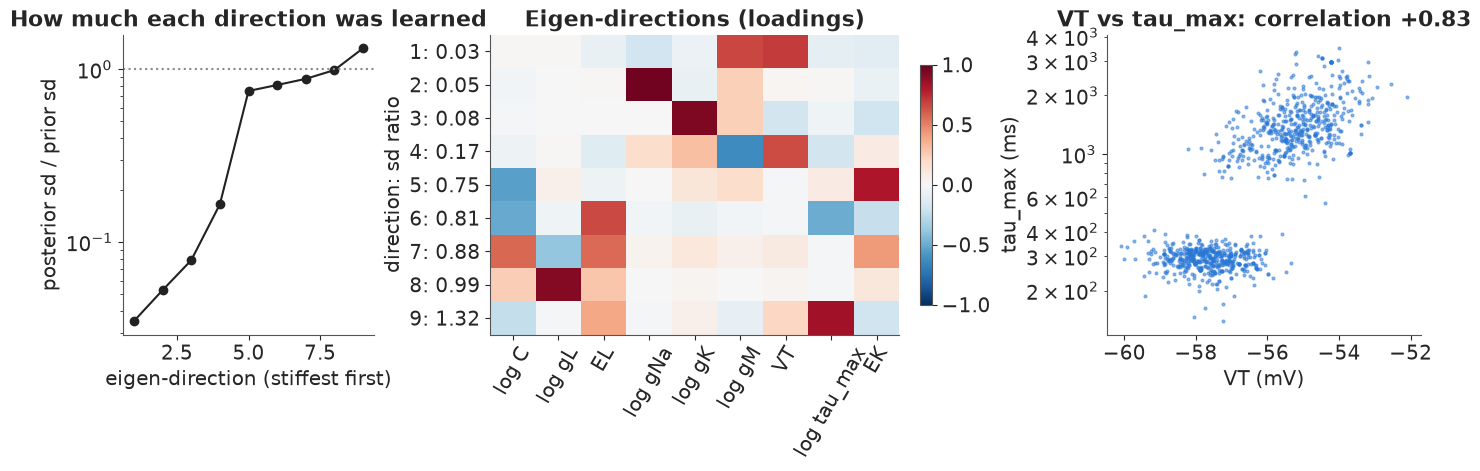

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), width_ratios=[0.8, 1.3, 1])
ax = axes[0]
ax.semilogy(np.arange(1, 10), np.sqrt(lam), "o-", color=INK)
ax.axhline(1.0, color=GREY, ls=":")
ax.set(xlabel="eigen-direction (stiffest first)", ylabel="posterior sd / prior sd",
       title="How much each direction was learned")
ax = axes[1]
im = ax.imshow(vec.T, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set(xticks=range(9), xticklabels=[("log " if il else "") + k for k, il in zip(PARAMS, is_log)],
       yticks=range(9), yticklabels=[f"{i + 1}: {np.sqrt(l):.2f}" for i, l in enumerate(lam)],
       ylabel="direction: sd ratio", title="Eigen-directions (loadings)")
ax.tick_params(axis="x", rotation=60)
fig.colorbar(im, ax=ax, shrink=0.8)
ax = axes[2]
top = np.argmax(np.abs(corr[iu]))
j1, j2 = iu[0][top], iu[1][top]
ax.scatter(draws[:, j1], draws[:, j2], s=4, color=BLUE, alpha=0.5)
ax.set(xscale="log" if is_log[j1] else "linear", yscale="log" if is_log[j2] else "linear",
       xlabel=f"{PARAMS[j1]} ({units[j1]})", ylabel=f"{PARAMS[j2]} ({units[j2]})",
       title=f"{PARAMS[j1]} vs {PARAMS[j2]}: correlation {corr[j1, j2]:+.2f}");

The eigen-spectrum (left) spans a factor of about 40: four directions were learned, narrowed 6- to
30-fold relative to the prior (sd ratios 0.03-0.17), and five were hardly learned at all (0.75-1.3).
The loadings (middle) show which combinations these are:

- the **stiffest** direction is $\log \bar g_M$ and $V_T$ together. More M-current makes the cell less
  excitable and so does a higher (less negative) $V_T$; the data fix their sum, and one can be traded
  for the other (their correlation is -0.62);
- the next two are $\log \bar g_{Na}$ and $\log \bar g_K$ almost alone: spike height and repolarisation;
- the fourth, much less stiff, is the difference between $V_T$ and $\log \bar g_M$;
- the **sloppy** five are $E_K$, $E_L$, $C$, $g_L$ (the last three held by the passive-fit prior, not
  by the spikes) and $\log \tau_{\max}$, whose ratio is above 1 because its two posterior modes spread
  it wider than the prior.

The right panel shows the strongest pairwise correlation, $V_T$ against $\tau_{\max}$ (+0.83): it is
not a ridge but the two separate modes. A covariance matrix summarises the posterior as one
Gaussian blob and cannot say "two islands"; look at the pairs as well as the eigenvalues.

**Degeneracy in action.** Take the two posterior draws that are furthest apart (in prior-sd units)
and simulate the 150 pA step with each.

distance 7.1 prior sds
                 C       gL       EL      gNa       gK       gM       VT  tau_max       EK
draw A        71.8      4.3    -66.7    632.1    163.5      5.2    -59.2    273.0    -95.7
draw B        81.0      4.5    -63.8    709.3    245.4      4.2    -54.4   2839.7    -94.0
ratio B/A     1.13     1.04     0.96     1.12     1.50     0.81     0.92    10.40     0.98
draw A: spikes at 90/150/210 pA = [ 7 33 60], width at 150 pA = 0.87 ms, trough = -57.6 mV
draw B: spikes at 90/150/210 pA = [ 4 36 62], width at 150 pA = 0.85 ms, trough = -55.6 mV


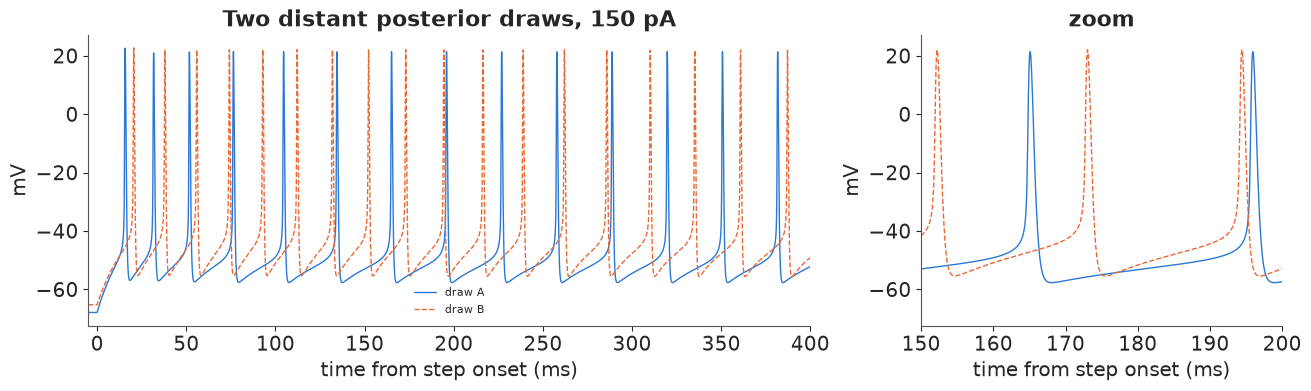

In [17]:
Zs = Z[sub_idx]
dist = np.linalg.norm(Zs[:, None, :] - Zs[None, :, :], axis=-1)
ia, ib = np.unravel_index(dist.argmax(), dist.shape)
th_a, th_b = draws[sub_idx[ia]], draws[sub_idx[ib]]
print(f"distance {dist[ia, ib]:.1f} prior sds")
print(" " * 9 + "".join(f"{k:>9s}" for k in PARAMS))
for lab, th in [("draw A", th_a), ("draw B", th_b)]:
    print(f"{lab:9s}" + "".join(f"{x:9.1f}" for x in th))
print("ratio B/A" + "".join(f"{x:9.2f}" for x in th_b / th_a))
va = simulate(th_a, 150.0, T_PRE + 1000.0)[:, 0]
vb = simulate(th_b, 150.0, T_PRE + 1000.0)[:, 0]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), width_ratios=[2, 1])
for ax, xl in zip(axes, [(-5, 400), (150, 200)]):
    ax.plot(T[: va.size] - T_ON, va, color=BLUE, lw=1, label="draw A")
    ax.plot(T[: vb.size] - T_ON, vb, color=ORANGE, lw=1, ls="--", label="draw B")
    ax.set(xlim=xl, xlabel="time from step onset (ms)", ylabel="mV")
axes[0].set_title("Two distant posterior draws, 150 pA")
axes[1].set_title("zoom")
axes[0].legend(fontsize=8)
for lab, th in [("A", th_a), ("B", th_b)]:
    f = features(th, FIT_AMPS)
    print(f"draw {lab}: spikes at 90/150/210 pA = {f[:, 0].astype(int)}, width at 150 pA = {f[1, 4]:.2f} ms, "
          f"trough = {f[1, 3]:.1f} mV")

The two draws come from the two modes: B has a ten times slower M-current, a threshold shift 5 mV
higher and 50% more delayed-rectifier conductance than A. They fire at the same rate (33 and 36
spikes at 150 pA), with the same spike width, and troughs 2 mV apart. The difference shows in the
first 100 ms: A's fast M-current slows its firing within two or three spikes, B's builds up more
gradually, so their spike times drift apart and stay out of step. That is exactly the difference a
trace likelihood would punish and a feature likelihood tolerates. For the physiologist this is the
point Marder and colleagues made: measuring the firing pattern does not determine the channel
densities, and cells of one type can reach the same behaviour with different channel mixes. For
the statistician it means: report and predict with the joint posterior, and never interpret one
marginal (say $\bar g_K$) as if the others were known.

## 7 · Predicting currents the model has not seen

The model was fitted to three current steps. We now predict all depolarising steps from 60 to
240 pA (nine recorded steps held out, including the near-threshold 70 and 80 pA ones, plus 240 pA
beyond the recorded range), with 200 posterior draws, and compare the f-I curve, the first-spike
latency and the AHP trough with the recordings.

In [18]:
PRED_AMPS = np.arange(60.0, 250.0, 10.0)
t0 = time.time()
F_pred = np.array([features(draws[i], PRED_AMPS) for i in sub_idx])   # (200, 19, 6)
print(f"{F_pred.shape[0] * F_pred.shape[1]} simulations in {time.time() - t0:.1f} s")
rec_amps = AMP[AMP >= 60]
F_rec = np.array([summarize(v, DT) for v in V_ALL[AMP >= 60]])
held = ~np.isin(rec_amps, FIT_AMPS)
lo, hi = np.quantile(F_pred[:, :, 0], [0.03, 0.97], axis=0)
inside = [(lo[PRED_AMPS == a][0] - 0.5 <= c <= hi[PRED_AMPS == a][0] + 0.5)
          for a, c in zip(rec_amps[held], F_rec[held, 0])]
print(f"held-out spike counts inside the 94% predictive interval: {sum(inside)} of {held.sum()}")
for a, c, ok in zip(rec_amps[held], F_rec[held, 0], inside):
    m_ = np.median(F_pred[:, PRED_AMPS == a, 0])
    print(f"  {a:5.0f} pA: recorded {c:3.0f}, predicted median {m_:5.1f} {'' if ok else '  <- outside'}")

3800 simulations in 9.2 s
held-out spike counts inside the 94% predictive interval: 4 of 9
     60 pA: recorded   0, predicted median   0.0 
     70 pA: recorded   1, predicted median   0.0   <- outside
     70 pA: recorded   0, predicted median   0.0 
     80 pA: recorded   2, predicted median   1.0   <- outside
    110 pA: recorded  19, predicted median  14.0   <- outside
    130 pA: recorded  27, predicted median  24.0   <- outside
    170 pA: recorded  42, predicted median  42.0 
    190 pA: recorded  48, predicted median  51.0 
    230 pA: recorded  61, predicted median  68.0   <- outside


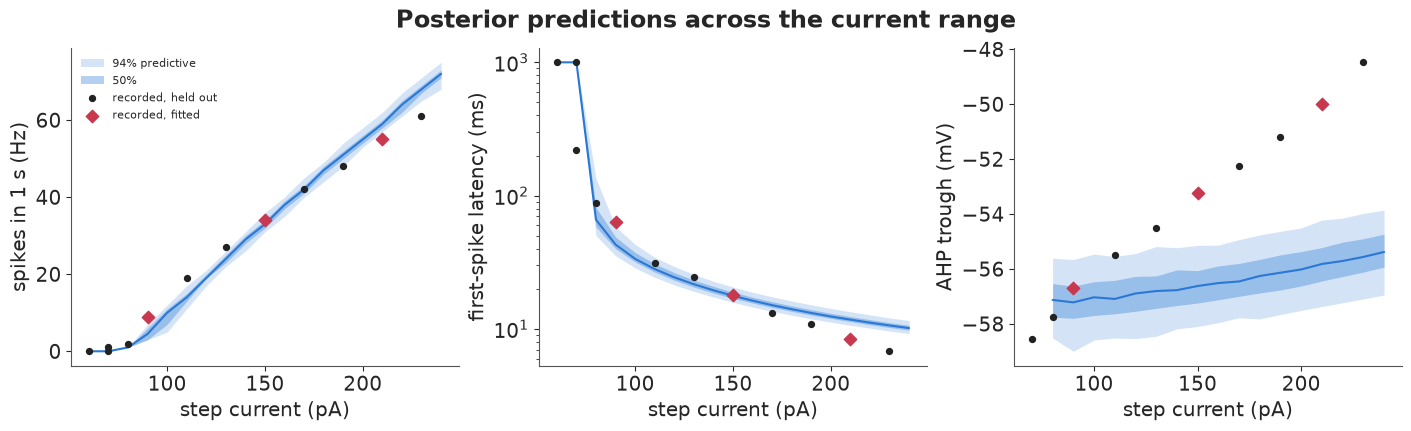

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, k, lab in zip(axes, [0, 1, 3], ["spikes in 1 s (Hz)", "first-spike latency (ms)", "AHP trough (mV)"]):
    val = F_pred[:, :, k]
    rec_val = F_rec[:, k]
    if k == 1:
        val, rec_val = np.exp(val), np.exp(rec_val)
    ok = F_pred[:, :, 0] > 0 if k == 3 else np.ones_like(val, bool)
    qs = np.array([np.quantile(val[ok[:, i], i], [0.03, 0.25, 0.5, 0.75, 0.97]) if ok[:, i].sum() > 10
                   else [np.nan] * 5 for i in range(PRED_AMPS.size)]).T
    ax.fill_between(PRED_AMPS, qs[0], qs[4], color=BLUE, alpha=0.2, lw=0, label="94% predictive")
    ax.fill_between(PRED_AMPS, qs[1], qs[3], color=BLUE, alpha=0.35, lw=0, label="50%")
    ax.plot(PRED_AMPS, qs[2], color=BLUE, lw=1.5)
    has = F_rec[:, 0] > 0 if k == 3 else np.ones(len(rec_amps), bool)
    ax.scatter(rec_amps[held & has], rec_val[held & has], color=INK, s=18, zorder=3, label="recorded, held out")
    ax.scatter(rec_amps[~held & has], rec_val[~held & has], color=RED, s=40, marker="D", zorder=3,
               label="recorded, fitted")
    ax.set(xlabel="step current (pA)", ylabel=lab)
axes[1].set(yscale="log")
axes[0].legend(fontsize=8)
fig.suptitle("Posterior predictions across the current range");

**f-I curve (left).** The model captures the overall shape (silent below about 80 pA, then a near
linear rise), and the held-out counts at 170 and 190 pA fall inside the predictive band. But its
f-I curve is **too steep**: it fires too little at low currents (14 against 19 spikes at 110 pA, 24
against 27 at 130, 1 against 2 at 80 pA, nothing against one spike at 70 pA) and too much at high
currents (68 against 61 at 230 pA). Only 4 of the 9 held-out counts are inside their 94% intervals.
The predictive bands are narrow because the posterior is confident about the f-I *slope*, and the
slope is the thing this model gets wrong. The **latency** (middle) is predicted well from 80 to
150 pA; at higher currents the cell starts firing sooner than the model (7 against about 10 ms at
230 pA). The **AHP trough** (right) is where the model is most clearly wrong: the recorded trough
rises by about 9 mV from 80 to 230 pA, the model's by less than 2 mV. These are structural misfits,
not parameter uncertainty, and no amount of posterior width covers them. A shallower f-I curve and
a shrinking AHP at high rates suggest a missing current that grows with firing (a calcium-activated
potassium current is a common candidate), which is exercise 2.

Finally, a held-out sweep: the 130 pA step, which the model never saw, with 30 posterior draws.

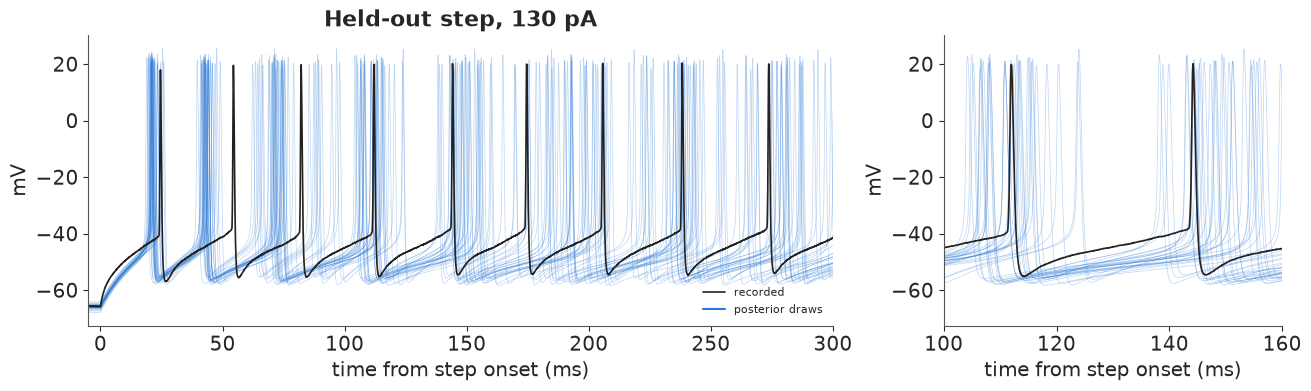

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), width_ratios=[2.2, 1])
v130 = sweep(130)
for ax, xl in zip(axes, [(-5, 300), (100, 160)]):
    for i in sub_idx[:30]:
        v = simulate(draws[i], 130.0, T_PRE + 350.0)[:, 0]
        ax.plot(T[: v.size] - T_ON, v, color=BLUE, lw=0.5, alpha=0.3)
    ax.plot(T - T_ON, v130, color=INK, lw=1.2, label="recorded")
    ax.set(xlim=xl, xlabel="time from step onset (ms)", ylabel="mV")
axes[0].plot([], [], color=BLUE, label="posterior draws")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_title("Held-out step, 130 pA");

The predicted spikes have the right height, width and shape. The first spike comes a few
milliseconds early (about 20-22 ms against 24) and the second one clearly early (in the 40s
against 54 ms): the model's early intervals are too short and its adaptation then catches up, as
in section 3. After about 100 ms the draws have fanned out over the whole interspike interval and
the recorded spikes fall inside that fan. This is the honest form of a spike-time prediction:
beyond the first few spikes even the posterior does not know where each spike will be, only
roughly how many there will be.

## Summary

- **Real data, a small file.** One Allen Cell Types neuron: the NWB file read with `h5py`, reduced
  to 21 current steps (450 KB) (section 1).
- **Passive properties are easy, with the right noise model**: a two-exponential charging curve
  with stationary AR(1) noise, fitted by NUTS in seconds, gives $R \approx 229$ MΩ,
  $\tau \approx 17$ ms, $C \approx 74$ pF, $g_L \approx 4.4$ nS. A held-out large step reveals a sag
  ($I_h$) that the passive model and our spiking model lack (section 2).
- **Stiff ODEs, cheaply**: Rush-Larsen (exponential Euler) updates each gate and the voltage with
  their exact linear solution; stable at the data's 0.05 ms spacing, 1.5 ms per simulated second
  in Numba, and differentiable in PyTensor `scan` (sections 3-4).
- **Trace matching is pathological**: the Gaussian trace likelihood has many local maxima (spike
  alignment); NUTS chains settle in different modes with r_hat about 1.55 and zero divergences,
  and the highest-likelihood mode makes no real spikes at all (section 4).
- **Feature likelihoods work**: a Gaussian on spike count, latency, peak, trough, width and
  adaptation, sampled with `pm.Simulator` + SMC in about two minutes, with agreeing chains that
  both found a two-mode posterior (section 5).
- **Sloppiness**: prior-whitened posterior eigen-directions span a factor of about 40; $\bar g_{Na}$,
  $\bar g_K$ and a combination of $\bar g_M$ and $V_T$ are learned, $E_K$ and $\tau_{\max}$ are not, and
  parameter sets from the two modes (a tenfold different M-current time constant) fire at the same
  rate with the same spikes (section 6).
- **Predictions** get the shape of the f-I curve and the latencies roughly right and expose the
  model's structural limits: an f-I curve that is too steep and an AHP that does not shrink with
  the firing rate (section 7).

## Try it yourself

1. **Tolerances.** Halve all feature scales $s_k$ and refit. Which marginals narrow, does the
   posterior predictive still cover the held-out f-I points, and do the SMC chains still agree?
   Then estimate the trial-to-trial part of $s_k$ from the Allen repeats (the NWB file has repeated
   2 s steps at 110 and 150 pA, sweeps 50-55) and compare it with the model-error part.
2. **Add a channel.** Give the model a calcium-activated potassium current (with a simple calcium
   pool that fills with each spike), or an $I_h$ for the sag of section 2, and add the AHP trend and
   the -110 pA sag amplitude to the features. Does the f-I slope improve, do the held-out counts
   move inside their intervals, and how does the sloppy spectrum change with one more conductance?
3. **Spike times instead of features.** Replace the Gaussian on spike counts by a likelihood on the
   interspike intervals (for example, each recorded ISI ~ LogNormal around the model's ISI at the
   same spike index). Does that sharpen $\bar g_K$ and $\bar g_M$ without bringing back the
   multimodality of section 4?